# E-Commerce Fraud Risk Classification
## Supervised Learning, SMOTE & Model Evaluation

### Project Overview

This project builds a supervised classification pipeline on the cleaned e-commerce dataset prepared in Project 1.

The analysis focuses on class imbalance, leakage-safe SMOTE, model training, hyperparameter tuning, and evaluation using **Precision, Recall, and ROC-AUC** rather than relying only on Accuracy.

### Important Data Limitation

The supplied e-commerce dataset does **not** contain a verified fraud label such as `Fraud` or `IsFraud`. Therefore, this notebook creates a clearly labelled **`FraudRiskFlag` proxy** from transaction characteristics to demonstrate the required fraud-classification workflow.

**This is not a real fraud ground-truth label.** The resulting model should be interpreted as a demonstration of a fraud-risk classification pipeline, not as a production fraud detector.

### Objectives

- Prepare the cleaned dataset for supervised learning.
- Create a transparent risk-label proxy because no fraud target is supplied.
- Measure class imbalance.
- Split the data before applying SMOTE.
- Use `imblearn.pipeline.Pipeline` to prevent resampling leakage during cross-validation.
- Train and tune Logistic Regression and Random Forest.
- Evaluate using Precision, Recall, ROC-AUC and confusion matrices.
- Compare the models and identify the stronger model for the proxy task.


## 1. Import Libraries

- **Pandas / NumPy:** data preparation and numerical operations.
- **Scikit-learn:** splitting, preprocessing, models, tuning and evaluation.
- **Imbalanced-learn:** SMOTE and leakage-safe pipelines.
- **Matplotlib / Seaborn:** visual analysis.


In [1]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, roc_auc_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


## 2. Load the Cleaned Dataset

In [3]:
df = pd.read_excel("Cleaned_Ecommerce_Data.xlsx")

print("Shape:", df.shape)
df.head()


Shape: (1200, 19)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,TotalPrice_Capped,PricePerItem,DiscountUsed,Weekend,OrderMonth
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2853.10,570.62,1,0,2023-01
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,302.70,151.35,1,0,2024-08
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2753.40,550.68,1,0,2024-02
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19,273.19,1,1,2023-10
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2504.04,626.01,1,0,2025-05


### Why the cleaned dataset is used

Project 2 starts from the cleaned/engineered dataset produced in Project 1. This avoids repeating data-cleaning work and gives the modeling stage a consistent input.


## 3. Check the Dataset Before Modeling

In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)


Missing values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode           0
ReferralSource       0
TotalPrice           0
TotalPrice_Capped    0
PricePerItem         0
DiscountUsed         0
Weekend              0
OrderMonth           0
dtype: int64

Duplicate rows: 0

Data types:
OrderID                      object
Date                 datetime64[ns]
CustomerID                   object
Product                      object
Quantity                      int64
UnitPrice                   float64
ShippingAddress              object
PaymentMethod                object
OrderStatus                  object
TrackingNumber               object
ItemsInCart                   int64
CouponCode                   object
ReferralSource               object
TotalPrice                  float6

### Observation

The dataset is already cleaned from Project 1. The main preprocessing tasks for this project are therefore target preparation, train/test splitting, imbalance handling, and model-specific preprocessing.


## 4. Create the Fraud-Risk Proxy Target

Because the supplied dataset has no real fraud label, we create `FraudRiskFlag` as a **proxy**.

A transaction is flagged as high-risk when:
- its order status is `Cancelled` or `Returned`, **and**
- it is either in the top 10% of transaction value, or has both relatively high quantity and cart size.

This rule is only a demonstration target. It must not be described as confirmed fraud.


In [5]:
amount_threshold = df["TotalPrice"].quantile(0.90)

df["FraudRiskFlag"] = (
    df["OrderStatus"].isin(["Cancelled", "Returned"]) &
    (
        (df["TotalPrice"] >= amount_threshold) |
        ((df["Quantity"] >= 4) & (df["ItemsInCart"] >= 7))
    )
).astype(int)

df["FraudRiskFlag"].value_counts()


FraudRiskFlag
0    1066
1     134
Name: count, dtype: int64

### Target distribution

The proxy label contains **134 high-risk transactions (11.17%)** and **1066 non-risk transactions (88.83%)**.

This creates a minority class, so a model that predicts the majority class most of the time could still look good on Accuracy. For this reason, Precision, Recall and ROC-AUC are more informative for this project.


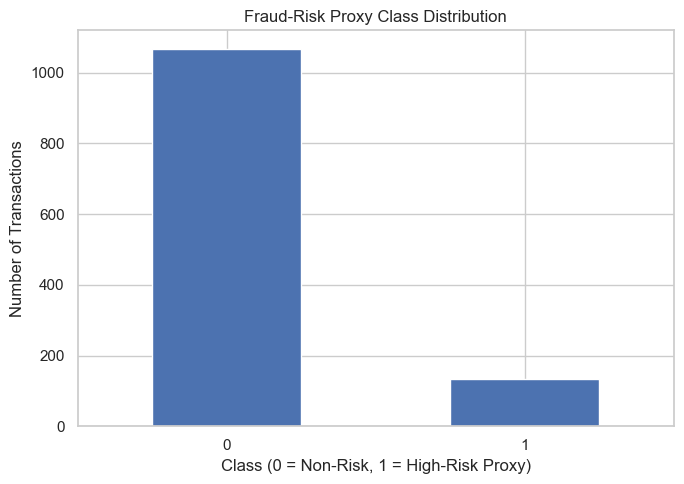

In [6]:
class_distribution = df["FraudRiskFlag"].value_counts()
class_distribution.plot(kind="bar", figsize=(7, 5))
plt.title("Fraud-Risk Proxy Class Distribution")
plt.xlabel("Class (0 = Non-Risk, 1 = High-Risk Proxy)")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Select Features

We use numerical/engineered transaction features:

- `Quantity`
- `UnitPrice`
- `ItemsInCart`
- `DiscountUsed`
- `Weekend`

### Leakage control

`OrderStatus` and `TotalPrice` are **not** included as model features because they were used when constructing the proxy target. Including them would allow the model to directly learn the rule used to create the label.


In [7]:
features = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "DiscountUsed",
    "Weekend"
]

X = df[features]
y = df["FraudRiskFlag"]

print("Features:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)


Features:
['Quantity', 'UnitPrice', 'ItemsInCart', 'DiscountUsed', 'Weekend']

X shape: (1200, 5)
y shape: (1200,)


## 6. Train/Test Split — Before SMOTE

The dataset is split before SMOTE.

This is critical: synthetic samples must never be created using the test set. Otherwise, information from the test set can leak into training and produce overly optimistic results.

We use a **stratified** split so the minority/majority ratio is approximately preserved in both sets.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())


Training set: (960, 5)
Test set: (240, 5)

Training class distribution:
FraudRiskFlag
0    853
1    107
Name: count, dtype: int64

Test class distribution:
FraudRiskFlag
0    213
1     27
Name: count, dtype: int64


## 7. SMOTE — Handling Class Imbalance

**SMOTE (Synthetic Minority Over-sampling Technique)** creates synthetic minority-class observations rather than simply duplicating existing rows.

We place SMOTE **inside an `imblearn.pipeline.Pipeline`**. This ensures that resampling happens only on the training portion of each cross-validation fold and prevents data leakage during GridSearchCV.


## 8. Logistic Regression Pipeline

Logistic Regression is a strong baseline for binary classification.

Because it is sensitive to feature scale, `StandardScaler` is placed before SMOTE and the classifier inside the same pipeline.


In [9]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

lr_params = {
    "model__C": [0.1, 1, 10],
    "smote__k_neighbors": [3, 5]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print("Best parameters:", lr_grid.best_params_)
print("Best CV ROC-AUC:", lr_grid.best_score_)


Best parameters: {'model__C': 0.1, 'smote__k_neighbors': 3}
Best CV ROC-AUC: 0.8882433653950683


## 9. Logistic Regression Evaluation

In [10]:
lr_pred = lr_grid.predict(X_test)
lr_prob = lr_grid.predict_proba(X_test)[:, 1]

lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("ROC-AUC:", lr_auc)

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))


Precision: 0.373134328358209
Recall: 0.9259259259259259
ROC-AUC: 0.9184489653973222

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.80      0.89       213
           1       0.37      0.93      0.53        27

    accuracy                           0.82       240
   macro avg       0.68      0.86      0.71       240
weighted avg       0.92      0.82      0.85       240



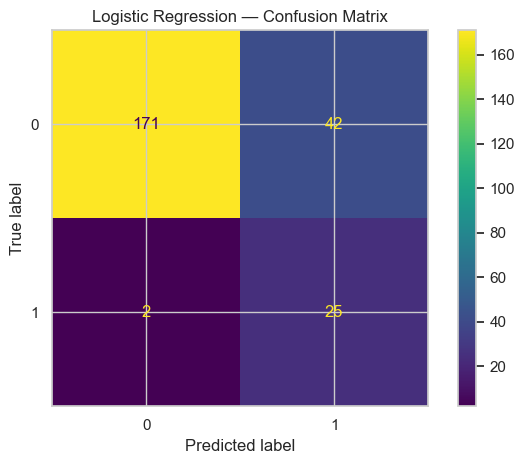

In [11]:
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()


## 10. Random Forest Pipeline

Random Forest is an ensemble of decision trees.

Unlike Logistic Regression, it does not require feature scaling. We therefore use SMOTE directly before the Random Forest model inside the imbalanced-learn pipeline.


In [12]:
rf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "smote__k_neighbors": [3, 5]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best CV ROC-AUC:", rf_grid.best_score_)


Best parameters: {'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 200, 'smote__k_neighbors': 3}
Best CV ROC-AUC: 0.9028510447241098


## 11. Random Forest Evaluation

In [13]:
rf_pred = rf_grid.predict(X_test)
rf_prob = rf_grid.predict_proba(X_test)[:, 1]

rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("ROC-AUC:", rf_auc)

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))


Precision: 0.4098360655737705
Recall: 0.9259259259259259
ROC-AUC: 0.8946270213875848

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.83      0.90       213
           1       0.41      0.93      0.57        27

    accuracy                           0.84       240
   macro avg       0.70      0.88      0.74       240
weighted avg       0.92      0.84      0.87       240



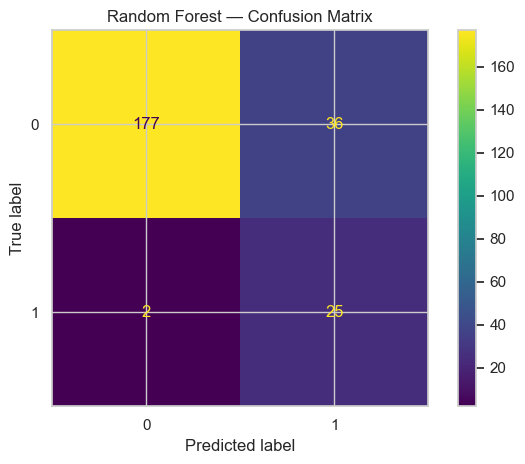

In [14]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()


## 12. Model Comparison

In [15]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [lr_precision, rf_precision],
    "Recall": [lr_recall, rf_recall],
    "ROC-AUC": [lr_auc, rf_auc]
})

results.sort_values("ROC-AUC", ascending=False)


,Model,Precision,Recall,ROC-AUC
0,Logistic Regression,0.373134,0.925926,0.918449
1,Random Forest,0.409836,0.925926,0.894627


### Result

For this particular proxy-label experiment:

- **Logistic Regression:** Precision = **0.373**, Recall = **0.926**, ROC-AUC = **0.918**
- **Random Forest:** Precision = **0.410**, Recall = **0.926**, ROC-AUC = **0.895**

Based on ROC-AUC, **Logistic Regression** performed better on the held-out test set, with ROC-AUC of approximately **0.918**.

The model comparison is valid for the **derived risk proxy**, not for real-world fraud detection.


## 13. ROC Curve Comparison

<Figure size 800x600 with 0 Axes>

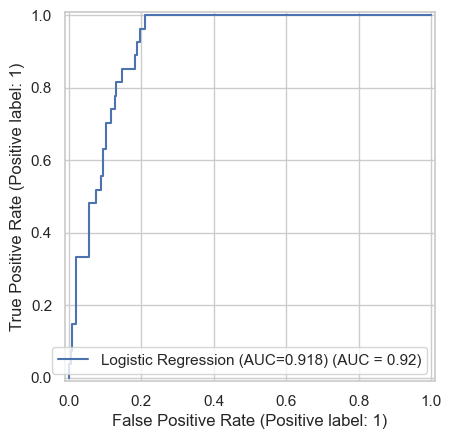

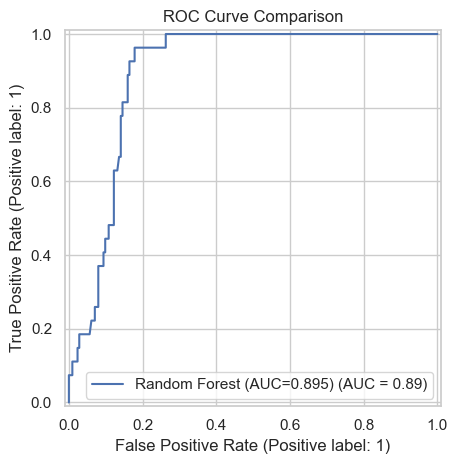

In [16]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    lr_prob,
    name=f"Logistic Regression (AUC={lr_auc:.3f})"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name=f"Random Forest (AUC={rf_auc:.3f})"
)

plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.show()


### Why ROC-AUC?

ROC-AUC measures how well the model separates the positive and negative classes across classification thresholds.

A value closer to 1 indicates stronger separation, while 0.5 represents performance close to random ranking.

For an imbalanced classification problem, ROC-AUC provides more useful information than Accuracy alone, although Precision and Recall are still essential for understanding the practical trade-off.


## 14. Precision vs Recall

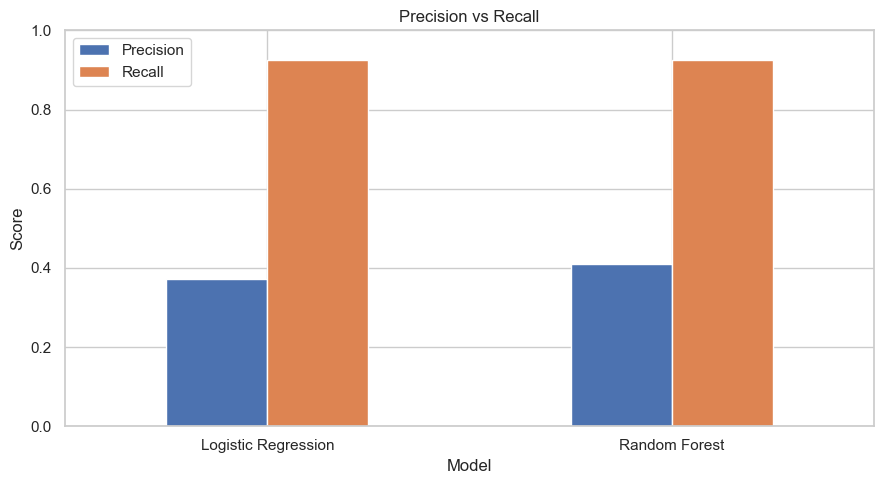

In [17]:
comparison = results.set_index("Model")[["Precision", "Recall"]]
comparison.plot(kind="bar", figsize=(9, 5))
plt.title("Precision vs Recall")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


### Interpretation

**Precision** answers: *When the model flags a transaction as risky, how often is that prediction correct?*

**Recall** answers: *Of all transactions labelled as risky, how many did the model successfully identify?*

For fraud-risk screening, Recall can be especially important because missing a genuinely risky transaction can be costly. However, very low Precision can create too many false alarms. The preferred operating threshold should therefore depend on the business cost of false positives and false negatives.


## 15. Final Business Interpretation

The pipeline demonstrates how an imbalanced binary classification problem can be handled without data leakage.

### Key technical decisions

1. The cleaned dataset from Project 1 was reused.
2. A transparent risk-proxy target was created because the supplied dataset contains no verified fraud label.
3. `OrderStatus` and `TotalPrice` were excluded from model features because they were used to define the proxy target.
4. Train/test splitting was performed before SMOTE.
5. SMOTE was placed inside an `imblearn` pipeline.
6. Logistic Regression and Random Forest were both trained.
7. GridSearchCV was used to tune hyperparameters using ROC-AUC.
8. Precision, Recall and ROC-AUC were used for evaluation.

### Business limitation

The current dataset cannot establish whether a transaction was actually fraudulent. A production fraud system would require historical, verified fraud labels from chargebacks, investigations, payment-provider decisions, or another trusted fraud source.

Therefore, the current result should be presented as a **fraud-risk classification pipeline demonstration**, not as a production fraud detector.


# Final Conclusion

The project successfully demonstrates a supervised-learning workflow for an imbalanced transaction-risk classification problem.

SMOTE was applied safely inside leakage-free pipelines, and both Logistic Regression and Random Forest were tuned using cross-validation. Precision, Recall and ROC-AUC were used instead of relying only on Accuracy.

The most important limitation is the absence of a verified fraud target in the supplied dataset. The `FraudRiskFlag` used here is a transparent proxy created for demonstrating the required machine-learning workflow.

For a real-world fraud detection system, the next step would be to replace this proxy with verified historical fraud labels and retrain the same pipeline on genuine outcomes.
